In [1]:
# @title
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader,random_split
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import copy
import random

In [3]:
# @title
batch_size = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_size = 50000
val_size = 10000
train_data, val_data = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


images, labels = next(iter(train_loader))
classes = train_dataset.classes
print(f"Image Shape :{images.shape}")
print(f"Batch Size {labels.shape}")
print("Classes in Data:",classes)
print(f"Train : {len(train_data)}")
print(f"Test: {len(test_dataset)}")

Image Shape :torch.Size([64, 1, 28, 28])
Batch Size torch.Size([64])
Classes in Data: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Train : 50000
Test: 10000


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Divece is : {device}")

Divece is : cuda


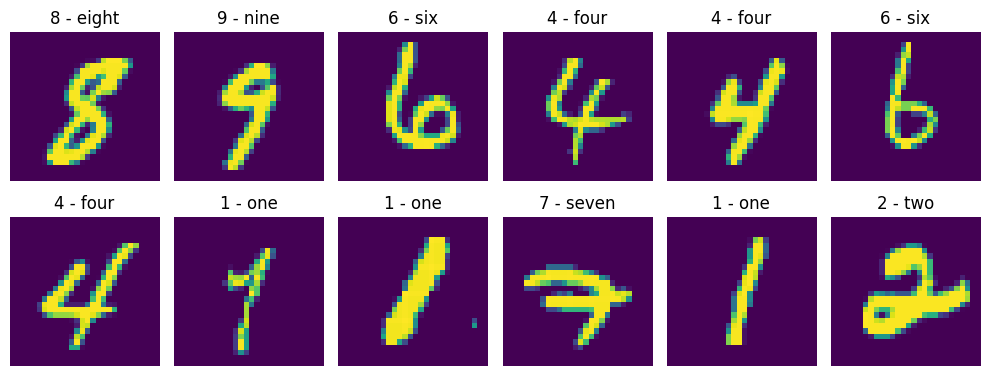

In [5]:
plt.figure(figsize=(10, 4))
for i in range(12):
  img,lable = random.choice(train_dataset)
  img = img.permute(1, 2, 0)*.5+.5
  plt.subplot(2, 6, i + 1)
  plt.imshow(img)
  plt.title(classes[lable])
  plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# @title
# simple Model
Model_Exp_1=nn.Sequential(
    nn.Flatten(),
    nn.Linear(784,128),
    nn.ReLU(),
    nn.Linear(128,10)
)
# Enhancement  Model
Model_Exp_2 = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(256, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 10)
)

In [8]:
criterion = nn.CrossEntropyLoss()
models = {
    'Simple Model': Model_Exp_1,
    'Enhanced Model (BatchNorm & Dropout)': Model_Exp_2
}

num_epochs = 30
all_results = {}

for model_name, model in models.items():
    print(f"Training model: {model_name}")

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []
    #Early Stop
    best_val_loss = float('inf')
    patience = 5
    counter = 0
    best_model_weights = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accuracies.append(epoch_acc)

        # Validation
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_epoch_loss = val_running_loss / len(val_loader)
        val_epoch_acc = 100 * val_correct / val_total
        val_losses.append(val_epoch_loss)
        val_accuracies.append(val_epoch_acc)
        # Scheduler
        scheduler.step()

        print(f'Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_loss:.4f},Train Acc: {epoch_acc:.2f}% | Val Loss: {val_epoch_loss:.4f},Val Acc: {val_epoch_acc:.2f}%')
        #Early Stoping
        if val_epoch_loss < best_val_loss:
            best_val_loss = val_epoch_loss
            counter = 0
            best_model_weights = copy.deepcopy(model.state_dict())
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    model.load_state_dict(best_model_weights)
    all_results[model_name] = {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }

Training model: Simple Model
Epoch [1/30] | Train Loss: 0.3995,Train Acc: 88.33% | Val Loss: 0.3039,Val Acc: 90.75%
Epoch [2/30] | Train Loss: 0.2123,Train Acc: 93.70% | Val Loss: 0.2089,Val Acc: 93.88%
Epoch [3/30] | Train Loss: 0.1536,Train Acc: 95.49% | Val Loss: 0.1679,Val Acc: 95.30%
Epoch [4/30] | Train Loss: 0.1239,Train Acc: 96.23% | Val Loss: 0.1365,Val Acc: 96.04%
Epoch [5/30] | Train Loss: 0.1031,Train Acc: 96.85% | Val Loss: 0.1262,Val Acc: 96.47%
Epoch [6/30] | Train Loss: 0.0671,Train Acc: 97.99% | Val Loss: 0.1060,Val Acc: 97.03%
Epoch [7/30] | Train Loss: 0.0619,Train Acc: 98.14% | Val Loss: 0.1044,Val Acc: 97.20%
Epoch [8/30] | Train Loss: 0.0597,Train Acc: 98.27% | Val Loss: 0.1046,Val Acc: 97.04%
Epoch [9/30] | Train Loss: 0.0577,Train Acc: 98.36% | Val Loss: 0.1032,Val Acc: 96.99%
Epoch [10/30] | Train Loss: 0.0559,Train Acc: 98.38% | Val Loss: 0.1021,Val Acc: 97.13%
Epoch [11/30] | Train Loss: 0.0519,Train Acc: 98.53% | Val Loss: 0.1000,Val Acc: 97.19%
Epoch [12/30

In [10]:
final_results = []

print("Test ")

for model_name, model in models.items():
    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / len(test_loader)
    test_acc = 100 * test_correct / test_total

    final_results.append({
        'Model': model_name,
        'Accuracy': f"{test_acc:.2f}%",
        'Loss': f"{test_loss:.4f}"
    })

df_final = pd.DataFrame(final_results)
print("-" * 60)
print(df_final.to_markdown(index=False))

Test 
------------------------------------------------------------
| Model                                | Accuracy   |   Loss |
|:-------------------------------------|:-----------|-------:|
| Simple Model                         | 97.42%     | 0.0839 |
| Enhanced Model (BatchNorm & Dropout) | 98.27%     | 0.0534 |


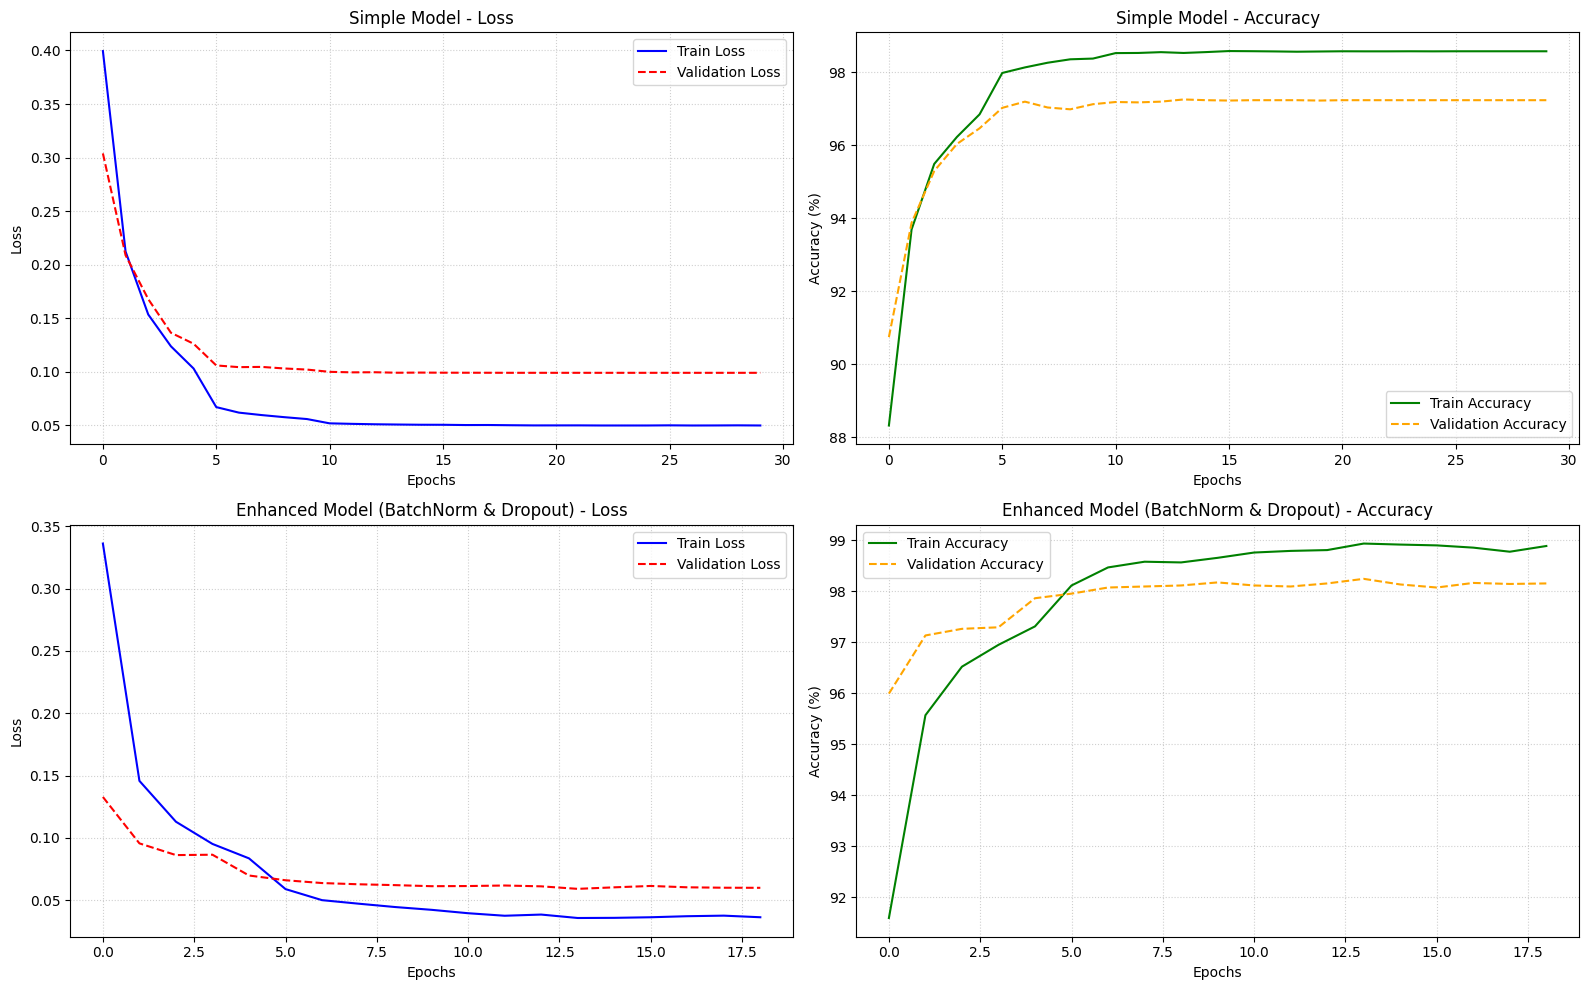

In [11]:

plt.figure(figsize=(16, 10))

for i, (model_name, metrics) in enumerate(all_results.items()):
    plt.subplot(2, 2, i*2 + 1)
    plt.plot(metrics['train_losses'], label='Train Loss', color='blue')
    plt.plot(metrics['val_losses'], label='Validation Loss', linestyle='--', color='red')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    plt.subplot(2, 2, i*2 + 2)
    plt.plot(metrics['train_accuracies'], label='Train Accuracy', color='green')
    plt.plot(metrics['val_accuracies'], label='Validation Accuracy', linestyle='--', color='orange')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()